# Loan Status Prediction

**Goal:** Predict whether a loan application will be approved (`1`) or rejected (`0`).


## 1. Import the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Load and Inspect the Dataset

In [2]:
DATA_PATH = "train_u6lujuX_CVtuZ9i (1).csv"

loan_dataset = pd.read_csv(DATA_PATH)

print("Dataset shape:", loan_dataset.shape)
loan_dataset.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Statistical summary of numerical columns
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
# Number of missing values in each column
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 3. Data Cleaning and Preprocessing

The original notebook used `dropna()`, so this version keeps that choice to make the modified project directly comparable to the original.

**Important limitation:** this removes every row containing at least one missing value. In this dataset, it reduces the data from 614 rows to 480 rows, so about 22% of the observations are discarded.

A stronger future version could use imputation instead.

In [5]:
# Drop rows containing missing values
loan_dataset = loan_dataset.dropna()

print("Shape after dropping missing values:", loan_dataset.shape)
print("Remaining missing values:")
print(loan_dataset.isnull().sum())

Shape after dropping missing values: (480, 13)
Remaining missing values:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


### Encode the target

In [6]:
# Loan_Status: N = 0 (Rejected), Y = 1 (Approved)
loan_dataset = loan_dataset.replace(
    {"Loan_Status": {"N": 0, "Y": 1}}
)

loan_dataset.head()

C:\Users\aayus\AppData\Local\Temp\ipykernel_27436\1640490334.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset = loan_dataset.replace(


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


### Handle the `Dependents` column

In [7]:
# The original dataset contains '3+'.
# We represent it as 4 to convert the column to numeric form.
loan_dataset = loan_dataset.replace(to_replace="3+", value=4)

loan_dataset["Dependents"].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

### Encode categorical variables

In [8]:
loan_dataset = loan_dataset.replace({
    "Married": {"No": 0, "Yes": 1},
    "Gender": {"Male": 1, "Female": 0},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Property_Area": {"Rural": 0, "Semiurban": 1, "Urban": 2},
    "Education": {"Graduate": 1, "Not Graduate": 0}
})

loan_dataset.head()

C:\Users\aayus\AppData\Local\Temp\ipykernel_27436\3591252701.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset = loan_dataset.replace({


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


## 4. Separate Features and Target

- `X` = input features used by the models
- `Y` = target we want to predict

`Loan_ID` is removed because it is only an identifier and should not be used as a predictive feature.

In [9]:
X = loan_dataset.drop(columns=["Loan_ID", "Loan_Status"], axis=1)
Y = loan_dataset["Loan_Status"]

print("Features:")
print(X.head())

print("\nTarget:")
print(Y.head())

Features:
   Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1       1        1          1          1              0             4583   
2       1        1          0          1              1             3000   
3       1        1          0          0              0             2583   
4       1        0          0          1              0             6000   
5       1        1          2          1              1             5417   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   
5             4196.0       267.0             360.0             1.0   

   Property_Area  
1              0  
2              2  
3              2  
4              2  
5              2 

## 5. Train-Test Split

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    stratify=Y,
    random_state=2
)

print("Full data:", X.shape)
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Full data: (480, 11)
Training data: (432, 11)
Test data: (48, 11)


### Why `stratify=Y`?

The target contains more approved loans than rejected loans. Stratification keeps a similar class proportion in the training and test sets.

### Why `random_state=2`?

It makes the split reproducible.

## 6. Model 1 — Logistic Regression

Logistic Regression is a binary classification model.

It estimates the probability that an observation belongs to class 1 (approved). A threshold is then used to convert the probability into a class prediction.

We use `StandardScaler` before Logistic Regression because the numerical features are on different scales.

The scaler is placed inside a `Pipeline` so that it is fitted only on the training data and is handled correctly during cross-validation.

In [11]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=2))
])

logistic_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## 7. Model 2 — Decision Tree

A Decision Tree learns a sequence of feature-based rules that splits observations into groups.

Unlike Logistic Regression, a tree can naturally learn nonlinear decision rules.

A major weakness of an unrestricted tree is overfitting, so we will compare its training and test performance.

In [12]:
tree_model = DecisionTreeClassifier(random_state=2)

tree_model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## 8. Model Evaluation

In [13]:
def evaluate_model(name, model, X_train, Y_train, X_test, Y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "Model": name,
        "Train Accuracy": accuracy_score(Y_train, train_pred),
        "Test Accuracy": accuracy_score(Y_test, test_pred),
        "Precision": precision_score(Y_test, test_pred, zero_division=0),
        "Recall": recall_score(Y_test, test_pred, zero_division=0),
        "F1 Score": f1_score(Y_test, test_pred, zero_division=0)
    }

    print(f"\n{name}")
    print("-" * len(name))
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, test_pred))
    print("\nClassification Report:")
    print(classification_report(Y_test, test_pred, zero_division=0))

    return results

logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_train, Y_train,
    X_test, Y_test
)

tree_results = evaluate_model(
    "Decision Tree",
    tree_model,
    X_train, Y_train,
    X_test, Y_test
)


Logistic Regression
-------------------
Confusion Matrix:
[[ 9  6]
 [ 2 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.60      0.69        15
           1       0.84      0.94      0.89        33

    accuracy                           0.83        48
   macro avg       0.83      0.77      0.79        48
weighted avg       0.83      0.83      0.83        48


Decision Tree
-------------
Confusion Matrix:
[[ 7  8]
 [ 4 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        15
           1       0.78      0.88      0.83        33

    accuracy                           0.75        48
   macro avg       0.71      0.67      0.68        48
weighted avg       0.74      0.75      0.74        48



## 9. Compare the Two Models

In [14]:
comparison = pd.DataFrame([logistic_results, tree_results])
comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805556,0.833333,0.837838,0.939394,0.885714
1,Decision Tree,1.000000,0.750000,0.783784,0.878788,0.828571


### Confusion matrices

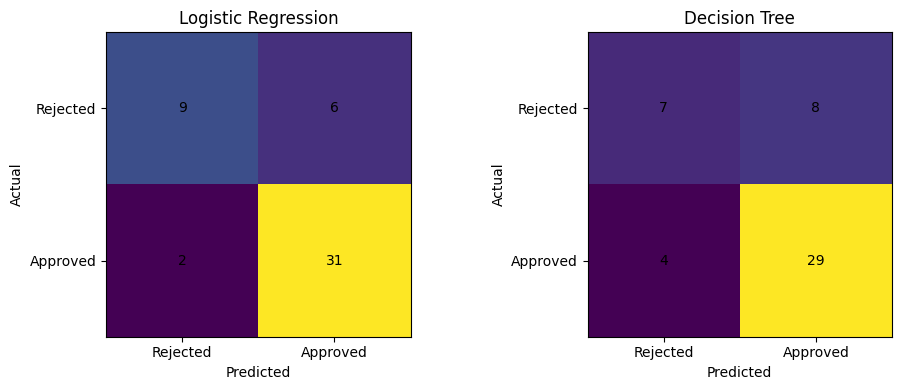

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(
    axes,
    [
        ("Logistic Regression", logistic_model),
        ("Decision Tree", tree_model)
    ]
):
    predictions = model.predict(X_test)
    cm = confusion_matrix(Y_test, predictions)

    ax.imshow(cm)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Rejected", "Approved"])
    ax.set_yticklabels(["Rejected", "Approved"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 10. Stratified 5-Fold Cross-Validation

A single 10% test split contains only 48 observations, so its result can vary noticeably depending on which observations land in the test set.

With 5-fold cross-validation, the data is divided into five stratified folds. Each fold is used as validation data once, while the other four folds are used for training.

We report the mean and standard deviation of the metrics.

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = []

for name, model in [
    ("Logistic Regression", logistic_model),
    ("Decision Tree", tree_model)
]:
    scores = cross_validate(
        model,
        X,
        Y,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean()
    })

cv_comparison = pd.DataFrame(cv_results)
cv_comparison

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean
0,Logistic Regression,0.804167,0.041353,0.792371,0.972863,0.873199
1,Decision Tree,0.670833,0.051286,0.771277,0.746902,0.758442


## 11. Interpretation

Based on this dataset and this exact preprocessing:

- Logistic Regression and Decision Tree are the only models considered.
- Logistic Regression performs substantially better than the unrestricted Decision Tree on cross-validation.
- The Decision Tree reaches very high training accuracy but substantially lower test/CV performance, which is evidence of overfitting.
- Accuracy should not be considered alone; precision, recall and F1-score provide additional information.
- The final model should be selected using validation performance and practical considerations, not simply training accuracy.

### Important limitations of this version

1. `dropna()` discards 134 of the original 614 rows.
2. The dataset is relatively small.
3. The holdout test set contains only 48 observations.
4. Some categorical variables are manually encoded as numbers; for example, `Property_Area` is encoded as 0/1/2 even though those categories are not naturally ordered.
5. Only two models are compared.
6. The Decision Tree is intentionally left unrestricted here so that its overfitting behavior is easy to observe. A later improvement could tune tree parameters such as `max_depth`.